### KMeans Clustering

https://www.kaggle.com/rammilan2612/driver-data

The Variables used are:
* Driver_ID
* Distance_Feature
* Speeding_Feature

In [118]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

### Load and read dataset

In [119]:
#load and read the first 10 samples
df = pd.read_csv('Driver_data.csv')
df.head(10)

,Driver_ID,Distance_Feature,Speeding_Feature
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25
5,3423313857,41.91,10
6,3423312432,58.64,20
7,3423311434,52.02,8
8,3423311328,31.25,34
9,3423312488,44.31,19


In [120]:
#print the shape
df.shape

(4000, 3)

In [121]:
#print the info
df.info

<bound method DataFrame.info of        Driver_ID  Distance_Feature  Speeding_Feature
0     3423311935             71.24                28
1     3423313212             52.53                25
2     3423313724             64.54                27
3     3423311373             55.69                22
4     3423310999             54.58                25
...          ...               ...               ...
3995  3423310685            160.04                10
3996  3423312600            176.17                 5
3997  3423312921            170.91                12
3998  3423313630            176.14                 5
3999  3423311533            168.03                 9

[4000 rows x 3 columns]>

In [122]:
#count the null values
df.isnull().count()

Driver_ID           4000
Distance_Feature    4000
Speeding_Feature    4000
dtype: int64

In [123]:
#print the exploratory statistics
df.describe

<bound method NDFrame.describe of        Driver_ID  Distance_Feature  Speeding_Feature
0     3423311935             71.24                28
1     3423313212             52.53                25
2     3423313724             64.54                27
3     3423311373             55.69                22
4     3423310999             54.58                25
...          ...               ...               ...
3995  3423310685            160.04                10
3996  3423312600            176.17                 5
3997  3423312921            170.91                12
3998  3423313630            176.14                 5
3999  3423311533            168.03                 9

[4000 rows x 3 columns]>

In [124]:
#feature selection
driver_data = df[['Distance_Feature', 'Speeding_Feature']]

#print the head of your dataframe
driver_data.head()

,Distance_Feature,Speeding_Feature
0,71.24,28
1,52.53,25
2,64.54,27
3,55.69,22
4,54.58,25


<Axes: xlabel='Distance_Feature', ylabel='Speeding_Feature'>

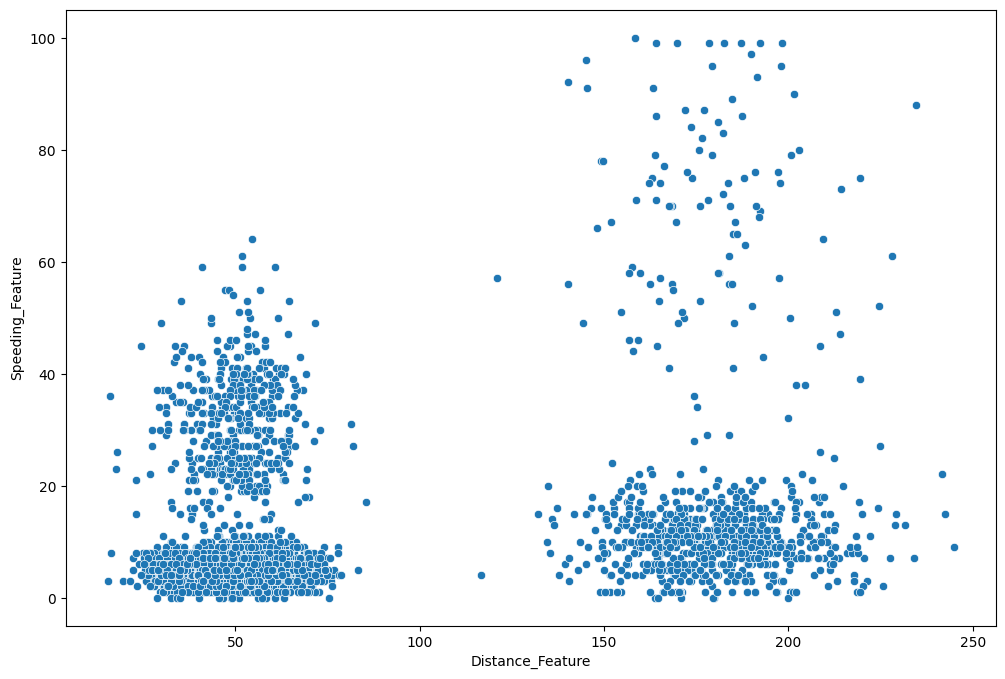

In [125]:
plt.figure(figsize = [12, 8])
sns.scatterplot(x = 'Distance_Feature', y = 'Speeding_Feature', data=driver_data)

<Figure size 1200x800 with 0 Axes>

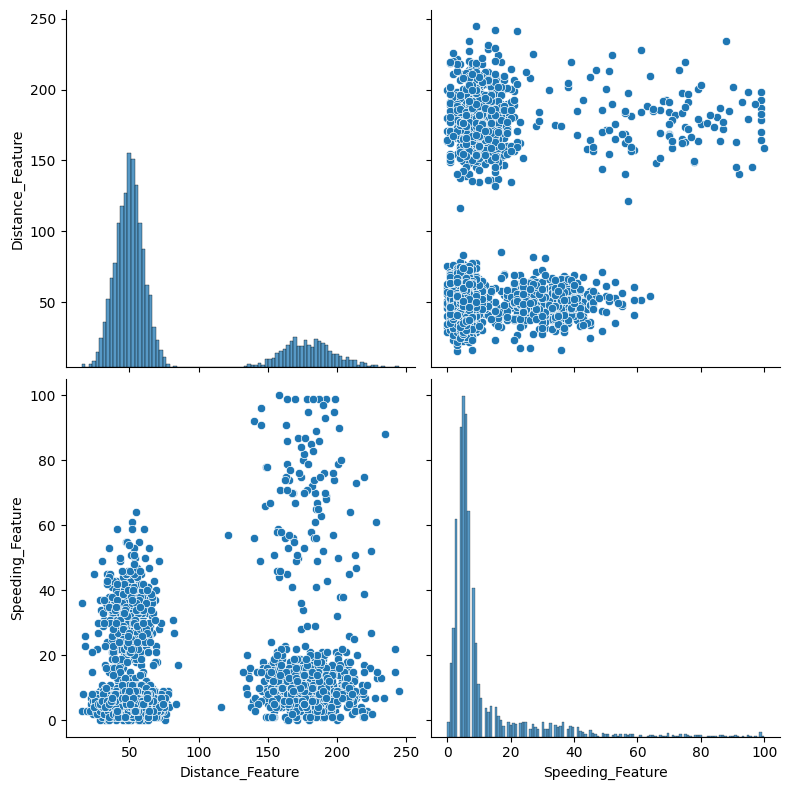

In [126]:
plt.figure(figsize = [12, 8])

sns.pairplot(driver_data, height = 4)

In [127]:
f1 = driver_data['Distance_Feature'].values

print(f1)

[ 71.24  52.53  64.54 ... 170.91 176.14 168.03]


In [128]:
f2 = driver_data['Speeding_Feature'].values

print(f2)

[28 25 27 ... 12  5  9]


In [129]:
X = np.array(list(zip(f1, f2)))

### Visualize Raw Data and initial centroids

In [130]:
k = 2

C_x = np.random.randint(0, np.max(X) - 20, size = k)
C_y = np.random.randint(0, np.max(X) - 20, size = k)

#### Plotting along with the Centroids

Text(0, 0.5, 'Speeding Feature')

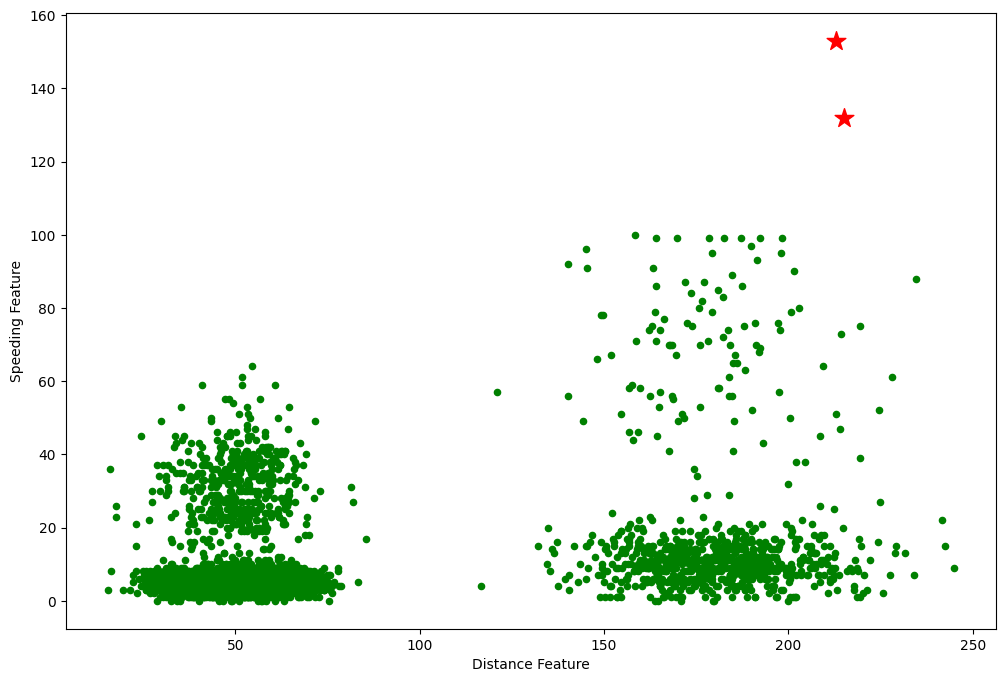

In [131]:
plt.figure(figsize = [12, 8])

plt.scatter(f1, f2, c = 'g', s = 20)

plt.scatter(C_x, C_y, marker = '*',
            c = 'r', s = 200)


plt.xlabel('Distance Feature')
plt.ylabel('Speeding Feature')

### Kmeans Model

#### K = 2

In [132]:
from sklearn.cluster import KMeans

#create kmeans model (kmeans_2) with k=2 and fit it on your data
kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto").fit(X)

In [133]:
#print the labels generated by the model
kmeans.labels_

array([0, 0, 0, ..., 1, 1, 1], shape=(4000,), dtype=int32)

In [134]:
#print the centroids
kmeans.cluster_centers_

array([[ 50.04763438,   8.82875   ],
       [180.017075  ,  18.29      ]])

In [135]:
#print the first 10 samples in order to do first observations on the clustering 
driver_data['kmeans_2_labels'] = kmeans.labels_
driver_data.sample(10)

,Distance_Feature,Speeding_Feature,kmeans_2_labels
122,35.25,53,0
3424,192.77,14,1
2604,50.70,7,0
1133,52.44,7,0
3788,162.58,1,1
2263,53.34,2,0
1412,45.39,6,0
241,50.91,51,0
2277,30.89,5,0
981,51.73,6,0


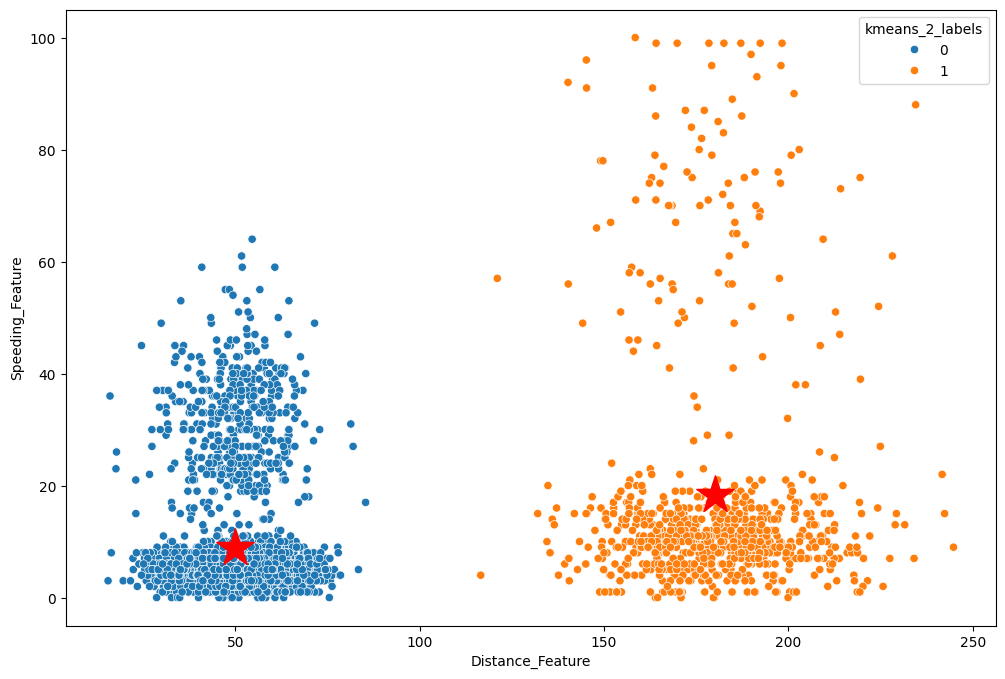

In [136]:
centroids = kmeans.cluster_centers_

plt.figure(figsize = [12, 8])

sns.scatterplot(x='Distance_Feature', y='Speeding_Feature',
                data=driver_data,
                hue='kmeans_2_labels')

plt.scatter(centroids[:, 0], centroids[:, 1],
            marker = '*', s = 800, c =  'r')

#### K = 4

In [137]:
#create kmeans model (kmeans_4) with k=4 and fit it on your data

from sklearn.cluster import KMeans

#create kmeans model (kmeans_2) with k=2 and fit it on your data
kmeans4 = KMeans(n_clusters=4, random_state=42, n_init="auto").fit(X)



In [138]:
kmeans4.labels_

array([2, 2, 2, ..., 1, 1, 1], shape=(4000,), dtype=int32)

In [139]:
kmeans4.cluster_centers_

array([[ 49.98428468,   5.21441441],
       [180.34311782,  10.52011494],
       [ 50.46127059,  32.42823529],
       [177.83509615,  70.28846154]])

In [140]:
driver_data['kmeans_4_labels'] = kmeans4.labels_
driver_data.sample(10)

,Distance_Feature,Speeding_Feature,kmeans_2_labels,kmeans_4_labels
3863,168.01,3,1,1
3799,196.37,17,1,1
1210,49.38,3,0,0
939,55.20,7,0,0
1479,46.39,6,0,0
2586,47.04,4,0,0
1188,51.19,5,0,0
3745,168.14,1,1,1
90,53.69,24,0,2
1238,29.65,3,0,0


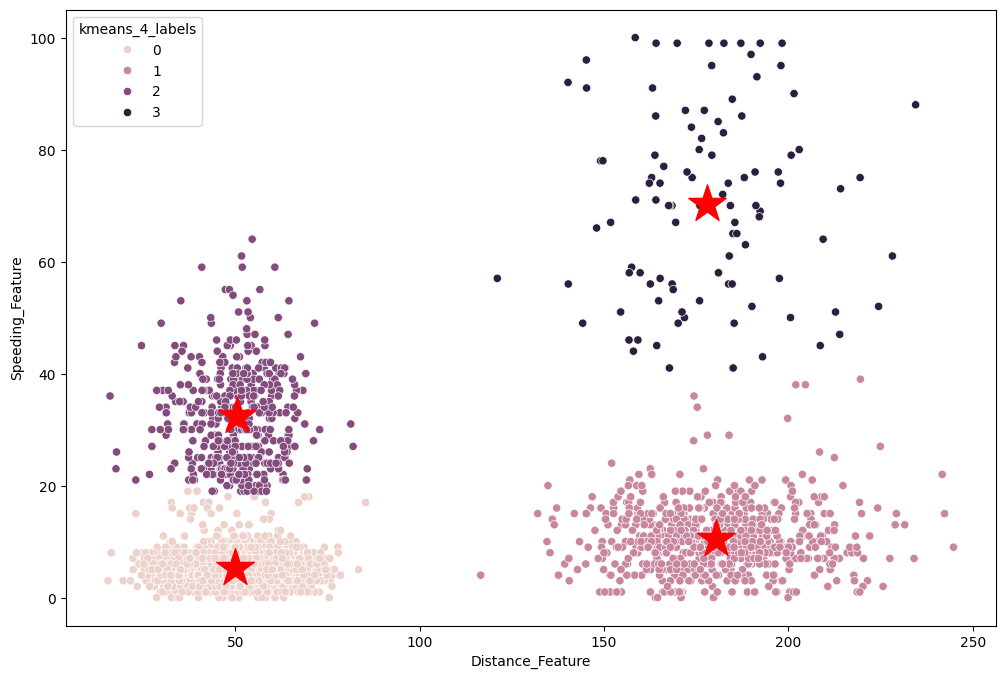

In [141]:
centroids = kmeans4.cluster_centers_

plt.figure(figsize=[12, 8])

sns.scatterplot(x='Distance_Feature', y='Speeding_Feature',
                data=driver_data,
                hue='kmeans_4_labels')

plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='*', s=800, c='r')

#### K = 6

In [142]:
#create kmeans model (kmeans_6) with k=6 and fit it on your data
from sklearn.cluster import KMeans

#create kmeans model (kmeans_2) with k=2 and fit it on your data
kmeans6 = KMeans(n_clusters=6, random_state=42, n_init="auto").fit(X)

In [143]:
#print the labels generated by the model
kmeans6.labels_

array([2, 2, 2, ..., 1, 1, 1], shape=(4000,), dtype=int32)

In [144]:
kmeans6.cluster_centers_

array([[ 57.66056718,   5.29304524],
       [166.49554974,  10.42408377],
       [ 50.61421836,  33.06203474],
       [176.63676768,  71.53535354],
       [197.25805643,  11.18495298],
       [ 41.30668693,   5.38677812]])

In [145]:
driver_data['kmeans_6_labels'] = kmeans6.labels_
driver_data.sample(10)

,Distance_Feature,Speeding_Feature,kmeans_2_labels,kmeans_4_labels,kmeans_6_labels
654,45.89,7,0,0,5
2442,56.09,6,0,0,0
3297,145.28,91,1,3,3
2073,43.42,8,0,0,5
1875,51.27,5,0,0,0
447,31.85,37,0,2,2
2637,34.04,9,0,0,5
3489,210.69,2,1,1,4
196,53.81,25,0,2,2
928,39.21,8,0,0,5


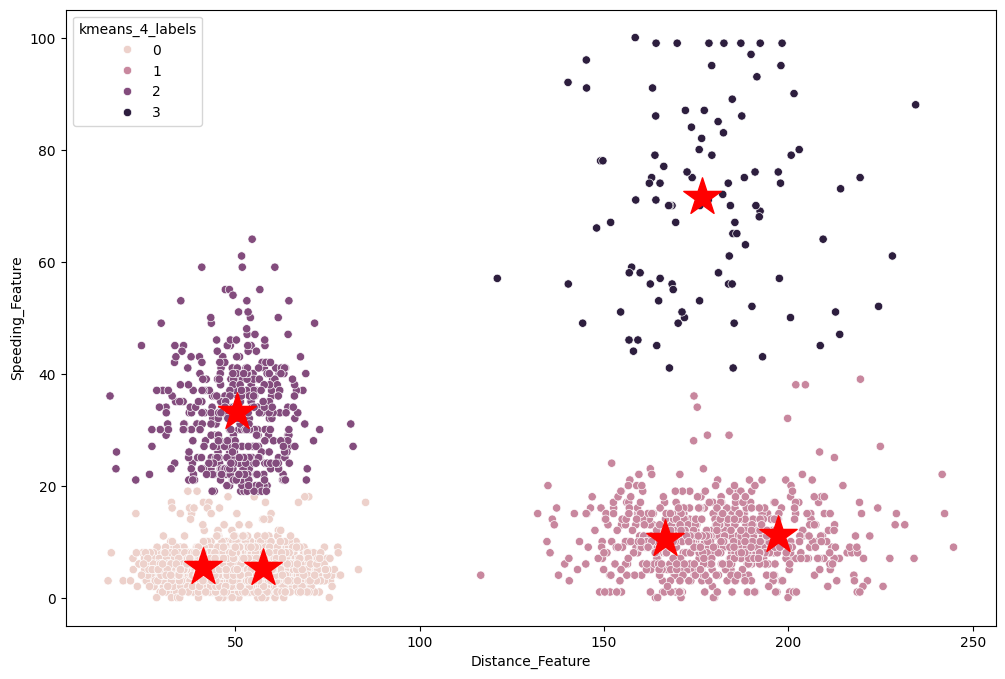

In [146]:
centroids = kmeans6.cluster_centers_

plt.figure(figsize=[12, 8])

sns.scatterplot(x='Distance_Feature', y='Speeding_Feature',
                data=driver_data,
                hue='kmeans_4_labels')

plt.scatter(centroids[:, 0], centroids[:, 1],
            marker='*', s=800, c='r')

### Evaluation

In [147]:
from sklearn import metrics

from sklearn.metrics import silhouette_score

#### Calculate Silhouette_score for K  = 2,  4 and 6

In [148]:
# print ss_2 : the silhouette_score of the model kmeans_2
silhouette_score(X, kmeans.fit_predict(X))

0.8490223286225532

In [149]:
# print ss_4 : the silhouette_score of the model kmeans_4

silhouette_score(X, kmeans4.fit_predict(X))

0.5911323766293183

In [150]:
# print ss_6 : the silhouette_score of the model kmeans_6
silhouette_score(X, kmeans6.fit_predict(X))

0.4857841597801742

In [151]:
# write your insights
#Le K2 est le meilleur car ca silhouette est la plus proche de 1.